In [212]:
import pandas as pd
import numpy as np
import json
#data loading
with open("C:/Users/Mehar Chhina/OneDrive/Documents/data/CUADv1.json","r") as f:
    data = json.load(f)

In [213]:
len(data['data'])

510

In [214]:
rows = []

In [215]:
for contract in data['data']:

    title = contract['title']

    for paragraph in contract['paragraphs']:

        context = paragraph['context']

        for qa in paragraph['qas']:

            label = qa['id'].split("__")[-1]

            for answer in qa['answers']:

                rows.append({
                    "contract_title": title,
                    "clause_category": label,
                    "clause_text": answer['text']
                })

In [216]:
df = pd.DataFrame(rows)

In [217]:
df.head()

,contract_title,clause_category,clause_text
0,LIMEENERGYCO_09_09_1999-EX-10-DISTRIBUTOR AGRE...,Document Name,DISTRIBUTOR AGREEMENT
1,LIMEENERGYCO_09_09_1999-EX-10-DISTRIBUTOR AGRE...,Parties,Distributor
2,LIMEENERGYCO_09_09_1999-EX-10-DISTRIBUTOR AGRE...,Parties,Electric City Corp.
3,LIMEENERGYCO_09_09_1999-EX-10-DISTRIBUTOR AGRE...,Parties,Electric City of Illinois L.L.C.
4,LIMEENERGYCO_09_09_1999-EX-10-DISTRIBUTOR AGRE...,Parties,Company


In [218]:
df["clause_category"].value_counts()

clause_category
Parties                               2554
License Grant                          777
Cap On Liability                       672
Anti-Assignment                        654
Audit Rights                           643
Insurance                              560
Document Name                          521
Agreement Date                         476
Expiration Date                        467
Governing Law                          464
Post-Termination Services              450
Effective Date                         447
Minimum Commitment                     424
Revenue/Profit Sharing                 418
Exclusivity                            410
Rofr/Rofo/Rofn                         367
Ip Ownership Assignment                318
Non-Transferable License               298
Non-Compete                            259
Change Of Control                      253
Termination For Convenience            246
Renewal Term                           210
Warranty Duration                     

In [219]:
df["clause_category"].nunique()

41

In [220]:
df["clause_category"].value_counts().head(20)

clause_category
Parties                      2554
License Grant                 777
Cap On Liability              672
Anti-Assignment               654
Audit Rights                  643
Insurance                     560
Document Name                 521
Agreement Date                476
Expiration Date               467
Governing Law                 464
Post-Termination Services     450
Effective Date                447
Minimum Commitment            424
Revenue/Profit Sharing        418
Exclusivity                   410
Rofr/Rofo/Rofn                367
Ip Ownership Assignment       318
Non-Transferable License      298
Non-Compete                   259
Change Of Control             253
Name: count, dtype: int64

In [221]:
df["clause_category"].value_counts().tail(20)

clause_category
Renewal Term                          210
Warranty Duration                     176
Covenant Not To Sue                   173
Volume Restriction                    171
Uncapped Liability                    167
Irrevocable Or Perpetual License      165
Competitive Restriction Exception     125
Notice Period To Terminate Renewal    122
Liquidated Damages                    121
Affiliate License-Licensee            115
Joint Ip Ownership                    115
No-Solicit Of Employees                91
Affiliate License-Licensor             69
Source Code Escrow                     66
Non-Disparagement                      65
No-Solicit Of Customers                58
Third Party Beneficiary                39
Most Favored Nation                    38
Unlimited/All-You-Can-Eat-License      32
Price Restrictions                     27
Name: count, dtype: int64

In [222]:
print(df.shape)

(13823, 3)


In [223]:
print(df.isnull().sum())

contract_title     0
clause_category    0
clause_text        0
dtype: int64


In [224]:
print(df.duplicated().sum())

0


In [225]:
df["clause_length"] = df["clause_text"].str.split().str.len()

df["clause_length"].describe()

count    13823.000000
mean        40.678290
std         43.445576
min          1.000000
25%          5.000000
50%         31.000000
75%         57.000000
max        479.000000
Name: clause_length, dtype: float64

In [226]:
#Defines mapping from fine-grained legal clause labels → coarse categories
LABEL_MAP = {

    # PARTIES (keep as is)
    "Parties": "PARTIES",

    # BUSINESS → split into BUSINESS + PRICING
    "Revenue/Profit Sharing": "BUSINESS",
    "Minimum Commitment": "BUSINESS",
    "Exclusivity": "BUSINESS",

    "Price Restrictions": "PRICING",
    "Volume Restriction": "PRICING",
    "Most Favored Nation": "PRICING",

    # LICENSE
    "License Grant": "LICENSE",
    "Non-Transferable License": "LICENSE",
    "Irrevocable Or Perpetual License": "LICENSE",
    "Unlimited/All-You-Can-Eat-License": "LICENSE",

    # IP
    "Ip Ownership Assignment": "IP",
    "Joint Ip Ownership": "IP",
    "Affiliate License-Licensee": "IP",
    "Affiliate License-Licensor": "IP",

    # LIABILITY
    "Cap On Liability": "LIABILITY",
    "Uncapped Liability": "LIABILITY",
    "Liquidated Damages": "LIABILITY",
    "Covenant Not To Sue": "LIABILITY",

    # TERMINATION
    "Termination For Convenience": "TERMINATION",
    "Notice Period To Terminate Renewal": "TERMINATION",
    "Expiration Date": "DATES",
    "Renewal Term": "DATES",

    # DOCUMENT
    "Document Name": "DOCUMENT_META",

    # DATES
    "Agreement Date": "DATES",
    "Effective Date": "DATES",

    # COMPLIANCE → split
    "Governing Law": "GOVERNANCE",
    "Third Party Beneficiary": "GOVERNANCE",

    "Audit Rights": "AUDIT",
    "Source Code Escrow": "AUDIT",

    # RESTRICTIONS
    "Non-Compete": "RESTRICTIONS",
    "No-Solicit Of Employees": "RESTRICTIONS",
    "No-Solicit Of Customers": "RESTRICTIONS",
    "Non-Disparagement": "RESTRICTIONS"
}

In [227]:
df["coarse_label"] = df["clause_category"].map(LABEL_MAP)

In [228]:
#Checks distribution of new grouped labels (including NaNs)
df["coarse_label"].value_counts(dropna=False)

coarse_label
NaN              2585
PARTIES          2554
DATES            1600
LICENSE          1272
BUSINESS         1252
LIABILITY        1133
AUDIT             709
IP                617
DOCUMENT_META     521
GOVERNANCE        503
RESTRICTIONS      473
TERMINATION       368
PRICING           236
Name: count, dtype: int64

In [229]:
#Removes rows that didn’t map to any coarse label
df = df[df["coarse_label"].notna()]

In [230]:
#Final class distribution after filtering
min_samples = 150

vc = df["coarse_label"].value_counts()
valid_classes = vc[vc >= min_samples].index

df = df[df["coarse_label"].isin(valid_classes)]

In [231]:
from sklearn.preprocessing import LabelEncoder
#Encodes categorical labels into numeric IDs for ML models
le = LabelEncoder()
df["label_id"] = le.fit_transform(df["coarse_label"])

In [232]:
from sklearn.model_selection import train_test_split

# 1. Encode the mapped coarse labels instead of the raw sparse labels
coarse_le = LabelEncoder()
df["coarse_label_id"] = coarse_le.fit_transform(df["coarse_label"])

# 2. Use the new dense target for the split
X_train, X_test, y_train, y_test = train_test_split(
    df["clause_text"],
    df["coarse_label_id"],  # Changed from label_id
    test_size=0.2,
    stratify=df["coarse_label_id"],  # Changed from label_id
    random_state=42
)

In [233]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(
    max_features=25000,
    ngram_range=(1, 3),
    min_df=2,
    max_df=0.9,
    sublinear_tf=True,
    stop_words='english'
)

X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

In [234]:
#Starts feature engineering pipeline
from scipy.sparse import hstack
from sklearn.preprocessing import StandardScaler
import pandas as pd

# 1. Extract metadata features
def extract_legal_features(series):
    feats = pd.DataFrame()
    feats['length'] = series.str.split().str.len()
    feats['has_shall'] = series.str.lower().str.contains('shall').astype(int)
    feats['has_may'] = series.str.lower().str.contains('may').astype(int)
    feats['has_liable'] = series.str.lower().str.contains('liable|liability').astype(int)
    return feats

train_feats = extract_legal_features(X_train)
test_feats = extract_legal_features(X_test)

# Scale features
scaler = StandardScaler()
X_train_feats_scaled = scaler.fit_transform(train_feats)
X_test_feats_scaled = scaler.transform(test_feats)

# 2. Combine the fixed TF-IDF matrices with custom numerical features and cast to CSR
X_train_vec = hstack([X_train_tfidf, X_train_feats_scaled]).tocsr()
X_test_vec = hstack([X_test_tfidf, X_test_feats_scaled]).tocsr()

# Verify shapes match systematically (+4 features over TF-IDF max_features)
print(f"Train matrix shape: {X_train_vec.shape}")
print(f"Test matrix shape: {X_test_vec.shape}")

Train matrix shape: (8990, 15004)
Test matrix shape: (2248, 15004)


In [235]:
from imblearn.over_sampling import RandomOverSampler
#Handles class imbalance by oversampling minority classes
ros = RandomOverSampler(random_state=42)

X_res, y_res = ros.fit_resample(X_train_vec, y_train)
model.fit(X_res, y_res)

CalibratedClassifierCV(estimator=LinearSVC(class_weight='balanced',
                                           max_iter=2000, random_state=42))

In [236]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(y_train),
    y=y_train
)

class_weight_dict = dict(zip(np.unique(y_train), weights))

In [237]:
LinearSVC(class_weight=class_weight_dict)

LinearSVC(class_weight={0: 1.321281599059377, 1: 0.7476713240186295,
                        2: 0.5852864583333334, 3: 1.79656274980016,
                        4: 1.863598673300166, 5: 1.5165317139001349,
                        6: 0.8268947755702722, 7: 0.7359201047806155,
                        8: 0.3666992984173601, 9: 3.9638447971781305,
                        10: 1.9819223985890653, 11: 2.548185941043084})

In [238]:
#Switches to SVM-based classifier
#More suitable for high-dimensional text data
#Calibration enables probability outputs
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV

# LinearSVC generally outperforms Logistic Regression on text classifications
base_model = LinearSVC(class_weight='balanced', random_state=42, max_iter=2000)

# Wrap it to retain probability outputs for proper risk-scoring evaluations
model = CalibratedClassifierCV(base_model, method='sigmoid')
model.fit(X_train_vec, y_train)

CalibratedClassifierCV(estimator=LinearSVC(class_weight='balanced',
                                           max_iter=2000, random_state=42))

In [239]:
from sklearn.metrics import classification_report

y_pred = model.predict(X_test_vec)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.95      0.96      0.96       142
           1       0.80      0.78      0.79       250
           2       0.92      0.88      0.90       320
           3       0.99      0.98      0.99       104
           4       0.96      0.99      0.98       101
           5       0.72      0.68      0.70       123
           6       0.95      0.90      0.93       227
           7       0.76      0.81      0.79       254
           8       0.97      0.99      0.98       511
           9       0.67      0.62      0.64        47
          10       0.84      0.91      0.87        95
          11       0.62      0.64      0.63        74

    accuracy                           0.88      2248
   macro avg       0.85      0.85      0.85      2248
weighted avg       0.88      0.88      0.88      2248



In [240]:
from sklearn.metrics import confusion_matrix

confusion_matrix(y_test, y_pred)

array([[137,   3,   0,   0,   0,   0,   0,   2,   0,   0,   0,   0],
       [  1, 194,   5,   1,   1,   5,   2,  26,   2,   8,   5,   0],
       [  0,   5, 283,   0,   0,   0,   1,   0,   4,   2,   1,  24],
       [  0,   0,   0, 102,   1,   0,   0,   0,   1,   0,   0,   0],
       [  0,   1,   0,   0, 100,   0,   0,   0,   0,   0,   0,   0],
       [  1,   3,   0,   0,   0,  84,   1,  26,   4,   1,   2,   1],
       [  0,   6,   1,   0,   1,   4, 205,   2,   3,   0,   3,   2],
       [  3,  17,   2,   0,   1,  19,   1, 206,   1,   0,   4,   0],
       [  0,   0,   0,   0,   0,   1,   0,   2, 508,   0,   0,   0],
       [  1,   9,   0,   0,   0,   2,   0,   5,   0,  29,   0,   1],
       [  1,   2,   0,   0,   0,   1,   2,   0,   1,   1,  86,   1],
       [  0,   3,  15,   0,   0,   0,   4,   1,   1,   2,   1,  47]],
      dtype=int64)

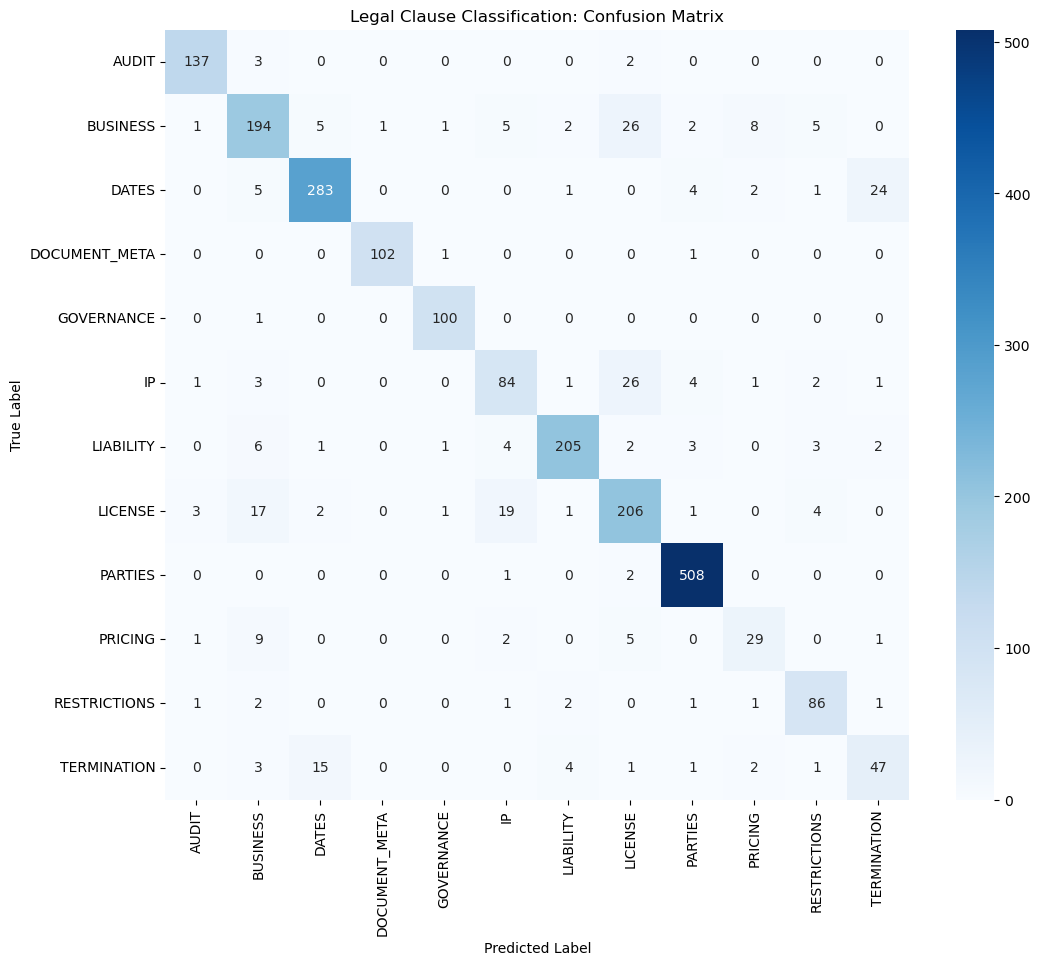

In [243]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Plot Confusion Matrix (Variable name fixed to y_pred)
plt.figure(figsize=(12, 10))
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(
    cm, 
    annot=True, 
    fmt='d', 
    xticklabels=target_names, 
    yticklabels=target_names, 
    cmap='Blues'
)

plt.title('Legal Clause Classification: Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()